# Modelo de previsão da necessidade de cobertura

Este notebook desenvolve a componente de previsão do projeto de escalonamento de equipas na hotelaria, com foco no departamento de Housekeeping (turnos T1 e T2).

O notebook está organizado em duas partes:

| Parte | Âmbito |
|---|---|
| **Modelo base** | Target: `colaboradores_minimos`, split 80/20 |
| **Extensão com validação temporal** | `TimeSeriesSplit` (5 folds) + target `colaboradores_ideais` |


## Carregamento dos dados

Neste bloco são carregadas as tabelas necessárias para a componente de previsão. O objetivo é reunir a informação operacional que servirá de base à construção do dataset de treino, nomeadamente os dados de atividade, atividade por tipologia e necessidades de cobertura.

In [26]:
from pathlib import Path
import pandas as pd
import numpy as np

# Modelação
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Caminho base dos dados
ROOT_DIR         = Path.cwd().parent
DATA_DIR         = ROOT_DIR / "data" / "synthetic"
DATA_DIR_OUTPUTS = ROOT_DIR / "outputs"
DATA_DIR_OUTPUTS.mkdir(parents=True, exist_ok=True)

# Carregamento dos ficheiros principais para a componente de previsão
colaboradores = pd.read_csv(DATA_DIR / "colaboradores.csv")
turnos = pd.read_csv(DATA_DIR / "turnos.csv")
cobertura = pd.read_csv(DATA_DIR / "cobertura_necessidades.csv")
disponibilidade = pd.read_csv(DATA_DIR / "disponibilidade.csv")
qualificacoes = pd.read_csv(DATA_DIR / "qualificacoes.csv")
preferencias = pd.read_csv(DATA_DIR / "preferencias.csv")
atividade = pd.read_csv(DATA_DIR / "atividade_hotel.csv")
tipologias_quarto = pd.read_csv(DATA_DIR / "tipologias_quarto.csv")
atividade_tipologia = pd.read_csv(DATA_DIR / "atividade_tipologia.csv")
recursos_externos = pd.read_csv(DATA_DIR / "recursos_externos.csv")

# Restringir ao contexto de Housekeeping: apenas T1 e T2
cobertura = cobertura[cobertura["turno_id"].isin(["T1", "T2"])].copy()

print("Cobertura após filtro T1/T2:")
print(cobertura["turno_id"].value_counts())
print("Dimensão:", cobertura.shape)

print("Ficheiros carregados com sucesso.")

# ── Semana-alvo para previsão (propagada para o Bloco 4 via gb_config.pkl) ────
# Alterar aqui para mudar a semana que o Bloco 4 vai otimizar
SEMANA_PREV_INICIO = "2025-01-01"
SEMANA_PREV_FIM    = "2025-01-07"

print(f"\nSemana-alvo para o Bloco 4: {SEMANA_PREV_INICIO} a {SEMANA_PREV_FIM}")

Cobertura após filtro T1/T2:
turno_id
T1    1095
T2    1095
Name: count, dtype: int64
Dimensão: (2190, 8)
Ficheiros carregados com sucesso.

Semana-alvo para o Bloco 4: 2025-01-01 a 2025-01-07


## Preparação temporal dos dados

As colunas de data relevantes são convertidas para o tipo `datetime`, de forma a permitir operações temporais necessárias à construção do dataset de treino e à criação de variáveis explicativas associadas ao tempo.

In [27]:
# Mesmo código utilizado no bloco 2 para garantir que as colunas de data estão no formato correto e autonomia entre os blocos 
atividade["data"] = pd.to_datetime(atividade["data"])
atividade_tipologia["data"] = pd.to_datetime(atividade_tipologia["data"])
cobertura["data"] = pd.to_datetime(cobertura["data"])

## Construção do dataset de treino

Neste bloco é construído o dataset de treino da componente de previsão. A variável-alvo será `colaboradores_minimos`, proveniente da tabela de **Necessidades de Cobertura**, e as features explicativas serão obtidas a partir da tabela de **Registo de Atividade** e de uma agregação diária da tabela **Atividade por Tipologia**.

Cada linha do dataset final corresponderá a uma combinação de **data, turno e função**.

In [28]:
# 1) Agregação diária da atividade por tipologia (soma diária de carga de limpeza, quartos checkout e stayover)
atv_tip_agg = (
    atividade_tipologia
    .groupby("data", as_index=False)
    .agg(
        carga_total_min=("carga_limpeza_min", "sum"),
        quartos_checkout_total=("quartos_checkout", "sum"),
        quartos_stayover_total=("quartos_stayover", "sum")
    )
)

atv_tip_agg.head()

,data,carga_total_min,quartos_checkout_total,quartos_stayover_total
0,2025-01-01,1616,16,46
1,2025-01-02,1099,11,35
2,2025-01-03,1357,17,40
3,2025-01-04,1542,16,51
4,2025-01-05,1557,21,37


In [29]:
# 2) Enriquecimento da tabela de atividade com as métricas agregadas por tipologia
atividade_modelo = atividade.merge(
    atv_tip_agg,
    on="data",
    how="left"
)

atividade_modelo.head()

,data,dia_semana,mes,tipo_dia,epoca,departamento,taxa_ocupacao,quartos_ocupados,total_quartos,n_checkins,n_checkouts,evento_especial,descricao_evento,quartos_a_limpar_estimados,carga_total_min,quartos_checkout_total,quartos_stayover_total
0,2025-01-01,Quarta,1,Feriado,Baixa,Housekeeping,0.52,62,120,24,16,0,Sem_evento,47,1616,16,46
1,2025-01-02,Quinta,1,Semana,Baixa,Housekeeping,0.39,46,120,16,11,0,Sem_evento,34,1099,11,35
2,2025-01-03,Sexta,1,Semana,Baixa,Housekeeping,0.48,57,120,22,17,0,Sem_evento,45,1357,17,40
3,2025-01-04,Sábado,1,Sabado,Baixa,Housekeeping,0.56,67,120,25,16,0,Sem_evento,49,1542,16,51
4,2025-01-05,Domingo,1,Domingo,Baixa,Housekeeping,0.49,58,120,22,21,0,Sem_evento,50,1557,21,37


In [30]:
# 3) Construção do dataset final de treino (merge da tabela anterior com a tabela de cobertura)
df_train = cobertura.merge(
    atividade_modelo,
    on="data",
    how="left"
)

df_train.head()

# Resolver colunas duplicadas após o merge
if "dia_semana_x" in df_train.columns and "dia_semana_y" in df_train.columns:
    df_train = df_train.rename(columns={"dia_semana_y": "dia_semana"})
    df_train = df_train.drop(columns=["dia_semana_x"])

In [31]:
# 4) Verificação da estrutura final
print("Dimensão do dataset de treino:", df_train.shape)
print("\nColunas disponíveis:")
print(df_train.columns.tolist())

Dimensão do dataset de treino: (2190, 23)

Colunas disponíveis:
['data', 'departamento_x', 'funcao', 'turno_id', 'colaboradores_minimos', 'colaboradores_ideais', 'origem_necessidade', 'dia_semana', 'mes', 'tipo_dia', 'epoca', 'departamento_y', 'taxa_ocupacao', 'quartos_ocupados', 'total_quartos', 'n_checkins', 'n_checkouts', 'evento_especial', 'descricao_evento', 'quartos_a_limpar_estimados', 'carga_total_min', 'quartos_checkout_total', 'quartos_stayover_total']


In [32]:
# 5) Seleção das colunas mais relevantes para a componente de previsão
colunas_modelo = [
    "data",
    "turno_id",
    "funcao",
    "colaboradores_minimos",
    "colaboradores_ideais",
    "taxa_ocupacao",
    "quartos_ocupados",
    "n_checkins",
    "n_checkouts",
    "evento_especial",
    "tipo_dia",
    "epoca",
    "mes",
    "dia_semana",
    "quartos_a_limpar_estimados",
    "carga_total_min",
    "quartos_checkout_total",
    "quartos_stayover_total"
]

df_modelo = df_train[colunas_modelo].copy()

print("Dimensão de df_modelo:", df_modelo.shape)
df_modelo.head()

Dimensão de df_modelo: (2190, 18)


,data,turno_id,funcao,colaboradores_minimos,colaboradores_ideais,taxa_ocupacao,quartos_ocupados,n_checkins,n_checkouts,evento_especial,tipo_dia,epoca,mes,dia_semana,quartos_a_limpar_estimados,carga_total_min,quartos_checkout_total,quartos_stayover_total
0,2025-01-01,T1,Empregada de andares,4,5,0.52,62,24,16,0,Feriado,Baixa,1,Quarta,47,1616,16,46
1,2025-01-01,T1,Supervisora,2,2,0.52,62,24,16,0,Feriado,Baixa,1,Quarta,47,1616,16,46
2,2025-01-01,T1,Auxiliar de limpeza,1,1,0.52,62,24,16,0,Feriado,Baixa,1,Quarta,47,1616,16,46
3,2025-01-01,T2,Empregada de andares,2,3,0.52,62,24,16,0,Feriado,Baixa,1,Quarta,47,1616,16,46
4,2025-01-01,T2,Supervisora,1,1,0.52,62,24,16,0,Feriado,Baixa,1,Quarta,47,1616,16,46


In [33]:
# 6) Verificação rápida de valores em falta
print("Valores nulos por coluna:")
print(df_modelo.isna().sum())

Valores nulos por coluna:
data                          0
turno_id                      0
funcao                        0
colaboradores_minimos         0
colaboradores_ideais          0
taxa_ocupacao                 0
quartos_ocupados              0
n_checkins                    0
n_checkouts                   0
evento_especial               0
tipo_dia                      0
epoca                         0
mes                           0
dia_semana                    0
quartos_a_limpar_estimados    0
carga_total_min               0
quartos_checkout_total        0
quartos_stayover_total        0
dtype: int64


## Preparação das features e da variável-alvo

Neste bloco são definidas a variável-alvo e as features explicativas do modelo de previsão. A variável a prever será `colaboradores_minimos`, enquanto as restantes variáveis relevantes serão utilizadas como inputs do modelo.

As variáveis categóricas serão codificadas para permitir a sua utilização nos algoritmos de aprendizagem supervisionada.

> **Nota:** o encoding one-hot e o split temporal são realizados nas células seguintes, após ordenação cronológica do dataset. O dataset está restrito aos turnos T1 e T2.

**Target principal — `colaboradores_minimos`:** valor usado pelo optimizer como hard constraint (cobertura mínima). Prever este valor evita leakage entre a componente preditiva e a componente de otimização.

**Target secundário — `colaboradores_ideais`:** valor usado pelo optimizer como referência para a soft constraint S4. A previsão do ideal produz resultados mais ambiciosos e operacionalmente mais úteis para a qualidade da escala gerada.

## Divisão entre treino e teste

Nesta etapa, o dataset é dividido em subconjuntos de treino e teste. Como a variável-alvo está associada a um horizonte temporal, opta-se por uma separação cronológica, utilizando os períodos iniciais para treino e os períodos mais recentes para teste.

Esta abordagem é mais adequada ao problema de previsão do que uma divisão aleatória, uma vez que respeita a estrutura temporal dos dados.

In [34]:
# Garantir ordenação cronológica
df_modelo = df_modelo.sort_values("data").reset_index(drop=True)

print(df_modelo[["data", "turno_id", "funcao", "colaboradores_minimos"]].head())
print(df_modelo[["data", "turno_id", "funcao", "colaboradores_minimos"]].tail())

        data turno_id                funcao  colaboradores_minimos
0 2025-01-01       T1  Empregada de andares                      4
1 2025-01-01       T1           Supervisora                      2
2 2025-01-01       T1   Auxiliar de limpeza                      1
3 2025-01-01       T2  Empregada de andares                      2
4 2025-01-01       T2           Supervisora                      1
           data turno_id                funcao  colaboradores_minimos
2185 2025-12-31       T1  Empregada de andares                      4
2186 2025-12-31       T1           Supervisora                      2
2187 2025-12-31       T1   Auxiliar de limpeza                      1
2188 2025-12-31       T2  Empregada de andares                      2
2189 2025-12-31       T2   Auxiliar de limpeza                      1


In [35]:
# Variável-alvo
target = "colaboradores_minimos"

# Features
features = [
    "turno_id", "funcao", "taxa_ocupacao", "quartos_ocupados",
    "n_checkins", "n_checkouts", "evento_especial", "tipo_dia",
    "epoca", "mes", "dia_semana", "quartos_a_limpar_estimados",
    "carga_total_min", "quartos_checkout_total", "quartos_stayover_total"
]

X = df_modelo[features].copy()
y = df_modelo[target].copy()

X_encoded = pd.get_dummies(
    X,
    columns=["turno_id", "funcao", "tipo_dia", "epoca", "dia_semana"],
    drop_first=False
)

# X_final é o que o split vai usar — linha que estava em falta
X_final = X_encoded.copy()

print("Dimensão de X_final:", X_final.shape)
print("Dimensão de y:", y.shape)
print("Turnos presentes:", df_modelo["turno_id"].unique())

Dimensão de X_final: (2190, 29)
Dimensão de y: (2190,)
Turnos presentes: ['T1' 'T2']


In [36]:
# Split temporal: 80% treino, 20% teste
# IMPORTANTE: split_idx calculado a partir de X_final para garantir consistência
split_idx = int(len(X_final) * 0.8)

X_train = X_final.iloc[:split_idx].copy()
X_test  = X_final.iloc[split_idx:].copy()

y_train = y.iloc[:split_idx].copy()
y_test  = y.iloc[split_idx:].copy()

# Verificação de consistência
assert len(X_train) + len(X_test) == len(X_final), "Erro no split de X"
assert len(y_train) + len(y_test) == len(y), "Erro no split de y"
assert len(X_test) == len(y_test), f"X_test ({len(X_test)}) != y_test ({len(y_test)})"

print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("y_train:", y_train.shape, "| y_test:", y_test.shape)

X_train: (1752, 29) | X_test: (438, 29)
y_train: (1752,) | y_test: (438,)


In [37]:
datas_train = df_modelo.iloc[:split_idx]["data"]
datas_test = df_modelo.iloc[split_idx:]["data"]

print("Período de treino:")
print(datas_train.min(), "até", datas_train.max())

print("\nPeríodo de teste:")
print(datas_test.min(), "até", datas_test.max())

Período de treino:
2025-01-01 00:00:00 até 2025-10-19 00:00:00

Período de teste:
2025-10-20 00:00:00 até 2025-12-31 00:00:00


> **Split temporal 80/20:** os registos mais antigos são usados para treino, os mais recentes para teste. Esta abordagem respeita a estrutura temporal dos dados e evita leakage futuro.

## Modelo baseline

Nesta etapa é treinado um modelo baseline para servir de referência inicial na componente de previsão. Primeiro será utilizado um modelo muito simples, que prevê sempre um valor central da variável-alvo, e depois uma regressão linear, de forma a obter uma primeira comparação com modelos mais avançados.

O objetivo deste bloco é perceber se os modelos seguintes, nomeadamente Random Forest e Gradient Boosting, conseguem melhorar de forma relevante o desempenho preditivo.

In [38]:
# Baseline 2: Regressão Linear
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

y_pred_lin = lin_model.predict(X_test)

print("Regressão Linear treinada com sucesso.")

Regressão Linear treinada com sucesso.


In [39]:
mae_lin = mean_absolute_error(y_test, y_pred_lin)
rmse_lin = np.sqrt(mean_squared_error(y_test, y_pred_lin))
r2_lin = r2_score(y_test, y_pred_lin)

print("Resultados — Regressão Linear")
print(f"MAE:  {mae_lin:.4f}")
print(f"RMSE: {rmse_lin:.4f}")
print(f"R²:   {r2_lin:.4f}")

Resultados — Regressão Linear
MAE:  0.4045
RMSE: 0.4839
R²:   0.8156


### Interpretação inicial do baseline

A regressão linear apresentou um desempenho inicial satisfatório na previsão da cobertura mínima. As variáveis operacionais seleccionadas capturam uma parte relevante da variabilidade da necessidade de cobertura, constituindo uma base de comparação para modelos mais flexíveis como Random Forest e Gradient Boosting.

## Random Forest Regressor

Nesta etapa é treinado um modelo **Random Forest Regressor** para prever a cobertura mínima necessária. Este modelo é mais flexível do que a regressão linear, permitindo captar relações não lineares e interações entre variáveis operacionais.

O desempenho do Random Forest será posteriormente comparado com o baseline de regressão linear.

In [40]:
# Random Forest Regressor
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# Verificação de consistência
assert len(y_pred_rf) == len(y_test), \
    f"Inconsistência: y_pred tem {len(y_pred_rf)} linhas, y_test tem {len(y_test)}"

print(f"Random Forest treinado. Previsões geradas: {len(y_pred_rf)} (esperado: {len(y_test)})")

Random Forest treinado. Previsões geradas: 438 (esperado: 438)


In [41]:
# Arredondamento das previsões do modelo principal (Random Forest)
y_pred_rf_round = np.maximum(1, np.round(y_pred_rf)).astype(int)

mae_rf_round = mean_absolute_error(y_test, y_pred_rf_round)
rmse_rf_round = np.sqrt(mean_squared_error(y_test, y_pred_rf_round))
r2_rf_round = r2_score(y_test, y_pred_rf_round)

print("Resultados — Random Forest arredondado por round")
print(f"MAE:  {mae_rf_round:.4f}")
print(f"RMSE: {rmse_rf_round:.4f}")
print(f"R²:   {r2_rf_round:.4f}")

Resultados — Random Forest arredondado por round
MAE:  0.2260
RMSE: 0.4754
R²:   0.8220


## Gradient Boosting Regressor

Nesta etapa é treinado um modelo **Gradient Boosting Regressor** para prever a cobertura mínima necessária. Tal como o Random Forest, este modelo permite captar relações não lineares entre as variáveis explicativas e a variável-alvo, mas fá-lo através de um processo sequencial de melhoria do erro.

O objetivo é avaliar se o Gradient Boosting consegue igualar ou superar o desempenho obtido pelo Random Forest.

In [42]:
# Gradient Boosting Regressor
gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)

print("Gradient Boosting treinado com sucesso.")

Gradient Boosting treinado com sucesso.


In [43]:
y_pred_gb_round = np.maximum(1, np.round(y_pred_gb)).astype(int)

mae_gb_round = mean_absolute_error(y_test, y_pred_gb_round)
rmse_gb_round = np.sqrt(mean_squared_error(y_test, y_pred_gb_round))
r2_gb_round = r2_score(y_test, y_pred_gb_round)

print("Resultados — Gradient Boosting arredondado por round")
print(f"MAE:  {mae_gb_round:.4f}")
print(f"RMSE: {rmse_gb_round:.4f}")
print(f"R²:   {r2_gb_round:.4f}")

Resultados — Gradient Boosting arredondado por round
MAE:  0.2009
RMSE: 0.4482
R²:   0.8418


## Comparação final dos modelos

Nesta etapa, os resultados dos três modelos testados são sintetizados num quadro comparativo, de forma a facilitar a avaliação do desempenho preditivo de cada abordagem.

A comparação será feita com base em três métricas:
- **MAE** — erro absoluto médio
- **RMSE** — raiz do erro quadrático médio
- **R²** — capacidade explicativa do modelo

In [44]:
resultados_finais = pd.DataFrame({
    "modelo": [
        "Regressão Linear",
        "Random Forest (round)",
        "Gradient Boosting (round)"
    ],
    "MAE": [
        mae_lin,
        mae_rf_round,
        mae_gb_round
    ],
    "RMSE": [
        rmse_lin,
        rmse_rf_round,
        rmse_gb_round
    ],
    "R²": [
        r2_lin,
        r2_rf_round,
        r2_gb_round
    ]
})

resultados_finais

,modelo,MAE,RMSE,R²
0,Regressão Linear,0.404524,0.483903,0.815578
1,Random Forest (round),0.226027,0.475423,0.821984
2,Gradient Boosting (round),0.200913,0.448233,0.841764


## Importância das features — Gradient Boosting

A importância das features indica o contributo relativo de cada variável para as
previsões do modelo. Features com maior importância são as que mais reduzem o erro
quando usadas para dividir os dados nas árvores de decisão.

Esta análise responde a uma questão operacional relevante: **quais os factores que
mais determinam a necessidade de cobertura?**

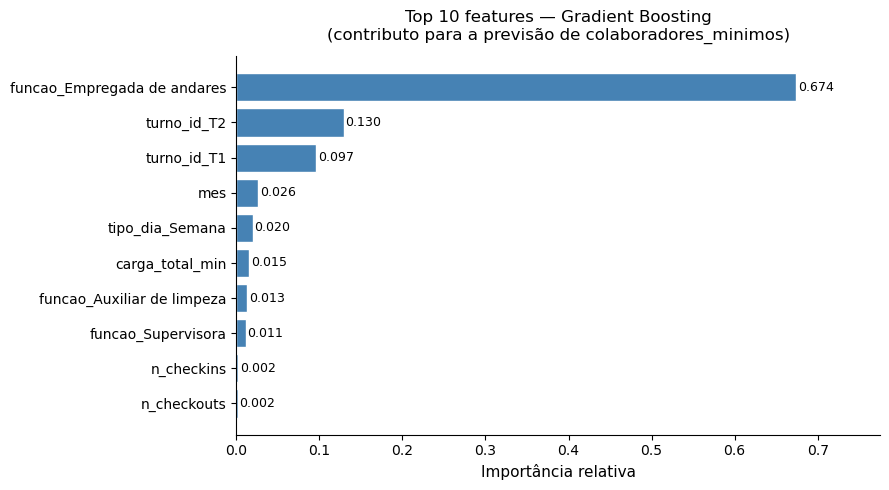

In [45]:
import matplotlib.pyplot as plt
import matplotlib

# ── Importância das features do Gradient Boosting ────────────────────────────
importancias = pd.Series(
    gb_model.feature_importances_,
    index=X_final.columns
).sort_values(ascending=False)

# Top 10
top10 = importancias.nlargest(10).sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(top10.index, top10.values, color='steelblue', edgecolor='white')

# Adicionar valores nas barras
for bar, val in zip(bars, top10.values):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

ax.set_xlabel('Importância relativa', fontsize=11)
ax.set_title('Top 10 features — Gradient Boosting\n(contributo para a previsão de colaboradores_minimos)',
             fontsize=12, pad=12)
ax.set_xlim(0, top10.max() * 1.15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


## Conclusão final da comparação dos modelos

A comparação final entre os modelos mostra que os algoritmos baseados em árvores superam
claramente a regressão linear na previsão da cobertura mínima necessária. O **Gradient
Boosting** é escolhido como modelo principal pela melhor combinação de MAE, RMSE e R².

### Limitações do split 80/20

O split 80/20 simples, embora válido para uma primeira versão, tem uma limitação
importante: avalia o modelo num único horizonte temporal fixo. Não sabemos se o
desempenho observado generaliza para diferentes períodos do ano.

A extensão com `TimeSeriesSplit` — validação cruzada
temporal com 5 folds que testa o modelo em múltiplos horizontes, incluindo épocas que
o modelo nunca viu durante o treino de cada fold.

---

# Extensão: validação temporal e segundo target

As secções seguintes implementam dois reforços metodológicos:

1. **Validação cruzada temporal** com `TimeSeriesSplit` (5 folds) — avaliação mais robusta que o split 80/20 simples
2. **Segundo target** (`colaboradores_ideais`) — prevê o número ideal de colaboradores, usado pelo optimizer como referência para S4


## Validação cruzada temporal — TimeSeriesSplit

O `TimeSeriesSplit` divide o dataset em 5 folds temporais consecutivos. Em cada fold,
o treino usa sempre dados anteriores ao teste — respeitando a ordem cronológica.

```
Fold 1: ████░░░░░░░░░░░░░░░░  treino=Jan-Mar | teste=Abr-Mai
Fold 2: ████████░░░░░░░░░░░░  treino=Jan-Mai | teste=Jun-Jul
Fold 3: ████████████░░░░░░░░  treino=Jan-Jul | teste=Ago-Set
Fold 4: ████████████████░░░░  treino=Jan-Set | teste=Out-Nov
Fold 5: ████████████████████  treino=Jan-Nov | teste=Dez
```

### Porquê é mais robusto que o split 80/20?
- O split 80/20 avalia o modelo num único horizonte fixo — pode ser favorável ou
  desfavorável por acaso
- O TimeSeriesSplit avalia em 5 horizontes distintos — incluindo épocas que o modelo
  nunca viu (fold 3 testa Agosto, época alta)
- O desvio-padrão dos resultados por fold mede a estabilidade do modelo ao longo do ano

### Aplicação: target `colaboradores_minimos`
Primeiro aplicamos o TSS ao target principal para comparação com o split 80/20.

In [46]:
# ── TimeSeriesSplit — target: colaboradores_minimos ───────────────
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

gb_params = dict(
    n_estimators     = 200,
    learning_rate    = 0.05,
    max_depth        = 3,
    min_samples_split= 10,
    min_samples_leaf = 5,
    random_state     = 42
)

target_v1 = "colaboradores_minimos"
y_v1 = df_modelo[target_v1].copy()

resultados_tss_v1 = []
print(f"TimeSeriesSplit (5 folds) — target: {target_v1}")
print(f"{'Fold':<6} {'Treino':>8} {'Teste':>8} {'MAE':>8} {'RMSE':>8} {'R²':>8}")
print("─" * 50)

for fold, (tr_idx, te_idx) in enumerate(tscv.split(X_final), start=1):
    X_tr, X_te = X_final.iloc[tr_idx], X_final.iloc[te_idx]
    y_tr, y_te = y_v1.iloc[tr_idx],    y_v1.iloc[te_idx]

    gb_fold = GradientBoostingRegressor(**gb_params)
    gb_fold.fit(X_tr, y_tr)
    y_pred = np.maximum(1, np.round(gb_fold.predict(X_te))).astype(int)  # round: N_min próximo do real

    mae_f  = mean_absolute_error(y_te, y_pred)
    rmse_f = np.sqrt(mean_squared_error(y_te, y_pred))
    r2_f   = r2_score(y_te, y_pred)
    resultados_tss_v1.append({"fold": fold, "MAE": mae_f, "RMSE": rmse_f, "R2": r2_f,
        "data_inicio_teste": df_modelo.iloc[te_idx[0]]["data"].strftime("%Y-%m-%d"),
        "data_fim_teste":    df_modelo.iloc[te_idx[-1]]["data"].strftime("%Y-%m-%d")})

    print(f"  {fold:<4} {len(tr_idx):>8} {len(te_idx):>8} {mae_f:>8.3f} {rmse_f:>8.3f} {r2_f:>8.3f}")

df_tss_v1 = pd.DataFrame(resultados_tss_v1)
print("─" * 50)
print(f"  {'Média':<4} {'':>8} {'':>8} {df_tss_v1['MAE'].mean():>8.3f} {df_tss_v1['RMSE'].mean():>8.3f} {df_tss_v1['R2'].mean():>8.3f}")
print(f"  {'Std':<4} {'':>8} {'':>8} {df_tss_v1['MAE'].std():>8.3f} {df_tss_v1['RMSE'].std():>8.3f} {df_tss_v1['R2'].std():>8.3f}")
print()
print(f"Referência split 80/20: MAE={mae_gb_round:.3f} | R²={r2_gb_round:.3f}")

TimeSeriesSplit (5 folds) — target: colaboradores_minimos
Fold     Treino    Teste      MAE     RMSE       R²
──────────────────────────────────────────────────
  1         365      365    0.156    0.402    0.871
  2         730      365    0.145    0.381    0.884
  3        1095      365    0.375    0.652    0.812
  4        1460      365    0.384    0.694    0.612
  5        1825      365    0.205    0.453    0.839
──────────────────────────────────────────────────
  Média                      0.253    0.516    0.804
  Std                       0.118    0.146    0.111

Referência split 80/20: MAE=0.201 | R²=0.842


## TimeSeriesSplit com target `colaboradores_ideais`

O target principal é `colaboradores_minimos` — o valor que o optimizer usa como
hard constraint (cobertura mínima obrigatória).

Nesta secção, o target passa a ser **`colaboradores_ideais`** — o valor que o optimizer
usa como referência para a soft constraint S4 (penalização por ficar abaixo do ideal).

### Porquê usar este target?
- O optimizer já garante o mínimo via H1 — não precisa de o prever
- O que é útil prever é o **ideal** — quantos colaboradores seriam óptimos,
  não apenas suficientes
- Prever `colaboradores_ideais` torna a soft constraint S4 mais informada
  e a escala gerada mais próxima das necessidades reais

### Comparação esperada
`colaboradores_ideais` é sistematicamente ≥ `colaboradores_minimos`. O modelo aprende uma curva ligeiramente mais alta — MAE e RMSE tendem a ser marginalmente superiores.

In [47]:
# ── TimeSeriesSplit — target: colaboradores_ideais ────────────────
target_v2 = "colaboradores_ideais"
y_v2 = df_modelo[target_v2].copy()

resultados_tss_v2 = []
print(f"TimeSeriesSplit (5 folds) — target: {target_v2}")
print(f"{'Fold':<6} {'Treino':>8} {'Teste':>8} {'MAE':>8} {'RMSE':>8} {'R²':>8} {'Período teste'}")
print("─" * 70)

for fold, (tr_idx, te_idx) in enumerate(tscv.split(X_final), start=1):
    X_tr, X_te = X_final.iloc[tr_idx], X_final.iloc[te_idx]
    y_tr, y_te = y_v2.iloc[tr_idx],    y_v2.iloc[te_idx]

    gb_fold = GradientBoostingRegressor(**gb_params)
    gb_fold.fit(X_tr, y_tr)
    y_pred = np.maximum(1, np.ceil(gb_fold.predict(X_te))).astype(int)

    mae_f  = mean_absolute_error(y_te, y_pred)
    rmse_f = np.sqrt(mean_squared_error(y_te, y_pred))
    r2_f   = r2_score(y_te, y_pred)
    d_ini  = df_modelo.iloc[te_idx[0]]["data"].strftime("%b %Y")
    d_fim  = df_modelo.iloc[te_idx[-1]]["data"].strftime("%b %Y")
    resultados_tss_v2.append({"fold": fold, "MAE": mae_f, "RMSE": rmse_f, "R2": r2_f})

    print(f"  {fold:<4} {len(tr_idx):>8} {len(te_idx):>8} {mae_f:>8.3f} {rmse_f:>8.3f} {r2_f:>8.3f}   {d_ini} → {d_fim}")

df_tss_v2 = pd.DataFrame(resultados_tss_v2)
print("─" * 70)
print(f"  {'Média':<4} {'':>8} {'':>8} {df_tss_v2['MAE'].mean():>8.3f} {df_tss_v2['RMSE'].mean():>8.3f} {df_tss_v2['R2'].mean():>8.3f}")
print(f"  {'Std':<4} {'':>8} {'':>8} {df_tss_v2['MAE'].std():>8.3f} {df_tss_v2['RMSE'].std():>8.3f} {df_tss_v2['R2'].std():>8.3f}")

TimeSeriesSplit (5 folds) — target: colaboradores_ideais
Fold     Treino    Teste      MAE     RMSE       R² Período teste
──────────────────────────────────────────────────────────────────────
  1         365      365    0.671    0.874    0.568   Mar 2025 → May 2025
  2         730      365    0.562    0.749    0.671   May 2025 → Jul 2025
  3        1095      365    0.540    0.735    0.809   Jul 2025 → Sep 2025
  4        1460      365    1.090    1.187    0.198   Sep 2025 → Nov 2025
  5        1825      365    0.608    0.780    0.633   Nov 2025 → Dec 2025
──────────────────────────────────────────────────────────────────────
  Média                      0.694    0.865    0.576
  Std                       0.227    0.188    0.229


## Comparação entre abordagens

Comparação entre as abordagens testadas: split 80/20 com target mínimo, validação temporal com target mínimo, e validação temporal com target ideal.

In [48]:
# ── Tabela comparativa entre abordagens ──────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

comp = pd.DataFrame([
    {
        "Abordagem": "Split 80/20",
        "Target"  : "colaboradores_minimos",
        "Método"  : "Split 80/20",
        "MAE"     : mae_gb_round,
        "RMSE"    : rmse_gb_round,
        "R²"      : r2_gb_round,
        "Folds"   : 1
    },
    {
        "Abordagem": "TSS — mínimo",
        "Método"  : "TimeSeriesSplit (5 folds)",
        "MAE"     : df_tss_v1["MAE"].mean(),
        "RMSE"    : df_tss_v1["RMSE"].mean(),
        "R²"      : df_tss_v1["R2"].mean(),
        "Folds"   : 5
    },
    {
        "Abordagem": "TSS — ideal",
        "Método"  : "TimeSeriesSplit (5 folds)",
        "MAE"     : df_tss_v2["MAE"].mean(),
        "RMSE"    : df_tss_v2["RMSE"].mean(),
        "R²"      : df_tss_v2["R2"].mean(),
        "Folds"   : 5
    }
])

comp["MAE"]  = comp["MAE"].round(3)
comp["RMSE"] = comp["RMSE"].round(3)
comp["R²"]   = comp["R²"].round(3)

print("Comparação entre abordagens:")
print(comp.to_string(index=False))
print()
print("Interpretação:")
print("  • MAE e RMSE mais altos no TSS reflectem avaliação mais exigente")
print("    (o modelo é testado em épocas que nunca viu — fold de época alta)")
print("  • colaboradores_ideais tem MAE ligeiramente superior ao mínimo,")
print("    como esperado — curva mais alta e variável")
print("  • A estabilidade (std por fold) é o indicador mais importante de robustez")

Comparação entre abordagens:
   Abordagem                Target                    Método   MAE  RMSE    R²  Folds
 Split 80/20 colaboradores_minimos               Split 80/20 0.201 0.448 0.842      1
TSS — mínimo                   NaN TimeSeriesSplit (5 folds) 0.253 0.516 0.804      5
 TSS — ideal                   NaN TimeSeriesSplit (5 folds) 0.694 0.865 0.576      5

Interpretação:
  • MAE e RMSE mais altos no TSS reflectem avaliação mais exigente
    (o modelo é testado em épocas que nunca viu — fold de época alta)
  • colaboradores_ideais tem MAE ligeiramente superior ao mínimo,
    como esperado — curva mais alta e variável
  • A estabilidade (std por fold) é o indicador mais importante de robustez


## Treinar modelo final no dataset completo

Após a validação com TimeSeriesSplit, o segundo modelo é treinado no **dataset completo**
(sem reservar dados para teste) com o target `colaboradores_ideais`.

Este é o modelo que será guardado e usado pelo Bloco 4 para prever os ideais da
semana-alvo — complementando o modelo de mínimos já treinado.

In [49]:
# ── Treinar modelo para colaboradores_ideais (dataset completo) ──────
gb_model_v2 = GradientBoostingRegressor(**gb_params)
gb_model_v2.fit(X_final, y_v2)

print(f"Modelo treinado (colaboradores_ideais):")
print(f"  Target  : {target_v2}")
print(f"  Método  : GradientBoostingRegressor (mesmos hiperparâmetros)")
print(f"  Dataset : {len(X_final)} registos (dataset completo, sem split)")
print(f"  Features: {X_final.shape[1]} colunas")
print()
print("Prevê colaboradores_ideais — usado pelo Bloco 4 para N_ideal.")

Modelo treinado (colaboradores_ideais):
  Target  : colaboradores_ideais
  Método  : GradientBoostingRegressor (mesmos hiperparâmetros)
  Dataset : 2190 registos (dataset completo, sem split)
  Features: 29 colunas

Prevê colaboradores_ideais — usado pelo Bloco 4 para N_ideal.


## Guardar modelos para integração com o Bloco 4

São guardados dois modelos e a semana-alvo:

| Ficheiro | Conteúdo | Usado em |
|---|---|---|
| `gb_model.pkl` | GB treinado para `colaboradores_minimos` | Bloco 4 → N_min |
| `gb_model_v2.pkl` | GB treinado para `colaboradores_ideais` | Bloco 4 → N_ideal |
| `gb_features.pkl` | Colunas após encoding (partilhado pelos dois modelos) | Ambos |
| `gb_config.pkl` | Semana-alvo `SEMANA_PREV_INICIO` / `SEMANA_PREV_FIM` | Bloco 4 |

Para mudar a semana que o Bloco 4 vai otimizar, alterar `SEMANA_PREV_INICIO` e `SEMANA_PREV_FIM` no início deste notebook e re-executar.

In [50]:
import joblib

# ── Guardar modelo para colaboradores_minimos ─────────────────────────
joblib.dump(gb_model,    DATA_DIR_OUTPUTS / "gb_model.pkl")
joblib.dump(list(X_final.columns), DATA_DIR_OUTPUTS / "gb_features.pkl")

# ── Guardar modelo para colaboradores_ideais ──────────────
joblib.dump(gb_model_v2, DATA_DIR_OUTPUTS / "gb_model_v2.pkl")
# gb_features.pkl é partilhado — as features são as mesmas para ambos os targets

# Guardar semana-alvo (propagada para o Bloco 4)
joblib.dump(
    {"semana_inicio": SEMANA_PREV_INICIO, "semana_fim": SEMANA_PREV_FIM},
    DATA_DIR_OUTPUTS / "gb_config.pkl"
)

print(f"gb_model.pkl     → {type(gb_model).__name__} (colaboradores_minimos)")
print(f"gb_model_v2.pkl  → {type(gb_model_v2).__name__} (colaboradores_ideais)")
print(f"gb_features.pkl  → {len(X_final.columns)} features (partilhado)")
print(f"gb_config.pkl    → semana {SEMANA_PREV_INICIO} a {SEMANA_PREV_FIM}")
print("\nPronto para carregar no Bloco 4.")

gb_model.pkl     → GradientBoostingRegressor (colaboradores_minimos)
gb_model_v2.pkl  → GradientBoostingRegressor (colaboradores_ideais)
gb_features.pkl  → 29 features (partilhado)
gb_config.pkl    → semana 2025-01-01 a 2025-01-07

Pronto para carregar no Bloco 4.


## Conclusão final da componente de previsão

Os resultados confirmam que os modelos baseados em árvores superam a regressão linear na previsão da cobertura necessária. Entre os modelos testados, o **Gradient Boosting com arredondamento por `round`** apresentou o melhor desempenho global — menor MAE, menor RMSE e maior R².

A validação com `TimeSeriesSplit` confirmou a robustez do modelo em múltiplos horizontes temporais, incluindo épocas não vistas durante o treino de cada fold.

O **Gradient Boosting** é adoptado como modelo preditivo principal:
- `gb_model.pkl` — prevê `colaboradores_minimos` → N_min (hard constraint H1)
- `gb_model_v2.pkl` — prevê `colaboradores_ideais` → N_ideal (soft constraint S4)